In [90]:
import pandas as pd

clean_df = pd.read_csv("../Data/Processed/online_retail_cleaned.csv")

# Recreate the Day 1 derived field in memory for Day 2 analysis.
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["Price"]

print("CustomerIQ — Day 2")
print("Cleaned dataset loaded successfully!")
print("Dataset shape:", clean_df.shape)
print("Revenue recreated in memory:", "Revenue" in clean_df.columns)


CustomerIQ — Day 2
Cleaned dataset loaded successfully!
Dataset shape: (779425, 9)
Revenue recreated in memory: True


In [91]:
print("COLUMNS")
print(clean_df.columns.tolist())

print("\nDATA TYPES")
print(clean_df.dtypes)

print("\nDATE RANGE")
print("Start:", clean_df["InvoiceDate"].min())
print("End:", clean_df["InvoiceDate"].max())

print("\nCUSTOMERS")
print("Unique customers:", clean_df["Customer ID"].nunique())

print("\nINVOICES")
print("Unique invoices:", clean_df["Invoice"].nunique())

COLUMNS
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue']

DATA TYPES
Invoice          int64
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
Revenue        float64
dtype: object

DATE RANGE
Start: 2009-12-01 07:45:00
End: 2011-12-09 12:50:00

CUSTOMERS
Unique customers: 5878

INVOICES
Unique invoices: 36969


In [92]:
clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"])

print("InvoiceDate converted successfully!")
print(clean_df["InvoiceDate"].dtype)

InvoiceDate converted successfully!
datetime64[us]


In [93]:
customer_orders = (
    clean_df
    .groupby("Customer ID")["Invoice"]
    .nunique()
)

print("CUSTOMER ORDER DISTRIBUTION")
print("---------------------------")

print("Minimum orders:", customer_orders.min())
print("Median orders:", customer_orders.median())
print("Average orders:", round(customer_orders.mean(), 2))
print("Maximum orders:", customer_orders.max())

CUSTOMER ORDER DISTRIBUTION
---------------------------
Minimum orders: 1
Median orders: 3.0
Average orders: 6.29
Maximum orders: 398


In [94]:
import pandas as pd

clean_df = pd.read_csv(
    "../Data/Processed/online_retail_cleaned.csv"
)

# Recreate the Day 1 derived field in memory for Day 2 analysis.
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["Price"]

print("Dataset loaded successfully!")
print("Shape:", clean_df.shape)
print("Revenue recreated in memory:", "Revenue" in clean_df.columns)

Dataset loaded successfully!
Shape: (779425, 9)
Revenue recreated in memory: True


In [95]:
print("COLUMNS")
print(clean_df.columns.tolist())

print("\nSHAPE")
print(clean_df.shape)

print("\nCUSTOMERS")
print(clean_df["Customer ID"].nunique())

print("\nINVOICES")
print(clean_df["Invoice"].nunique())

COLUMNS
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue']

SHAPE
(779425, 9)

CUSTOMERS
5878

INVOICES
36969


In [96]:
clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"])

print("InvoiceDate data type:")
print(clean_df["InvoiceDate"].dtype)

InvoiceDate data type:
datetime64[us]


In [97]:
# Calculate number of unique orders per customer

customer_orders = (
    clean_df
    .groupby("Customer ID")["Invoice"]
    .nunique()
)

print("CUSTOMER ORDER DISTRIBUTION")
print("---------------------------")
print(f"Minimum orders: {customer_orders.min()}")
print(f"Median orders: {customer_orders.median()}")
print(f"Average orders: {customer_orders.mean():.2f}")
print(f"Maximum orders: {customer_orders.max()}")

CUSTOMER ORDER DISTRIBUTION
---------------------------
Minimum orders: 1
Median orders: 3.0
Average orders: 6.29
Maximum orders: 398


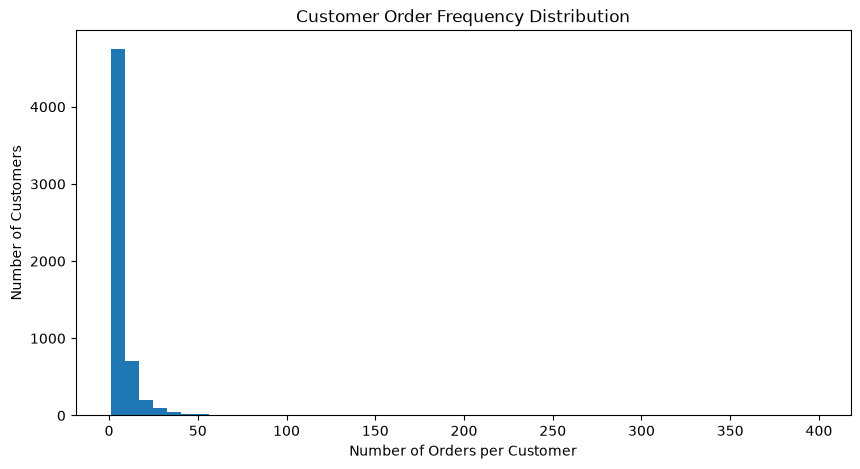

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(customer_orders, bins=50)

plt.xlabel("Number of Orders per Customer")
plt.ylabel("Number of Customers")
plt.title("Customer Order Frequency Distribution")

plt.show()

In [99]:
# Create the customer-order table and calculate consecutive-order intervals
customer_order_table = (
    clean_df[["Customer ID", "Invoice", "InvoiceDate", "Revenue"]]
    .drop_duplicates(subset=["Customer ID", "Invoice"])
    .sort_values(["Customer ID", "InvoiceDate"])
    .copy()
)

customer_order_table["DaysSincePreviousOrder"] = (
    customer_order_table
    .groupby("Customer ID")["InvoiceDate"]
    .diff()
    .dt.total_seconds()
    .div(24 * 60 * 60)
)

print("CUSTOMER-ORDER TABLE AND INTER-PURCHASE INTERVALS")
print("-------------------------------------------------")
print("Rows:", len(customer_order_table))
print("Customers:", customer_order_table["Customer ID"].nunique())
print("Invoices:", customer_order_table["Invoice"].nunique())
print("First orders without a previous interval:", customer_order_table["DaysSincePreviousOrder"].isna().sum())
print("Observed intervals:", customer_order_table["DaysSincePreviousOrder"].notna().sum())
print("Negative intervals:", (customer_order_table["DaysSincePreviousOrder"] < 0).sum())

display(customer_order_table.head(10))

CUSTOMER-ORDER TABLE AND INTER-PURCHASE INTERVALS
-------------------------------------------------
Rows: 36969
Customers: 5878
Invoices: 36969
First orders without a previous interval: 5878
Observed intervals: 31091
Negative intervals: 0


,Customer ID,Invoice,InvoiceDate,Revenue,DaysSincePreviousOrder
20719,12346.0,491725,2009-12-14 08:34:00,45.00,NaN
20962,12346.0,491742,2009-12-14 11:00:00,22.50,0.101389
20963,12346.0,491744,2009-12-14 11:02:00,22.50,0.001389
27601,12346.0,492718,2009-12-18 10:47:00,22.50,3.989583
27612,12346.0,492722,2009-12-18 10:55:00,1.00,0.005556
30272,12346.0,493410,2010-01-04 09:24:00,22.50,16.936806
30273,12346.0,493412,2010-01-04 09:53:00,22.50,0.020139
36682,12346.0,494450,2010-01-14 13:50:00,22.50,10.164583
43478,12346.0,495295,2010-01-22 13:30:00,22.50,7.986111
76157,12346.0,499763,2010-03-02 13:08:00,3.25,38.984722


In [100]:
# Summarize observed inter-purchase intervals
intervals = customer_order_table["DaysSincePreviousOrder"].dropna()

interval_statistics = intervals.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]).rename({
    "50%": "median",
    "25%": "25th_percentile",
    "75%": "75th_percentile",
    "90%": "90th_percentile",
    "95%": "95th_percentile"
})

print("INTER-PURCHASE INTERVAL STATISTICS (DAYS)")
print("-----------------------------------------")
display(interval_statistics.to_frame(name="Days"))

INTER-PURCHASE INTERVAL STATISTICS (DAYS)
-----------------------------------------


,Days
count,31091.000000
mean,51.686656
std,75.788911
min,0.000000
25th_percentile,6.983333
median,24.743056
75th_percentile,61.810417
90th_percentile,134.875694
95th_percentile,206.426736
max,714.152083


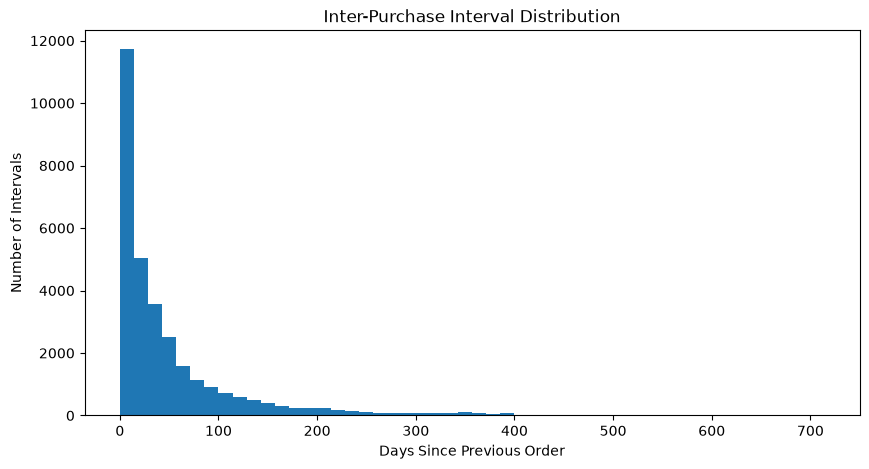

In [101]:
# Plot the observed interval distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(intervals, bins=50)
plt.xlabel("Days Since Previous Order")
plt.ylabel("Number of Intervals")
plt.title("Inter-Purchase Interval Distribution")
plt.show()

In [102]:
# Inspect provisional customer frequency tiers
customer_frequency = customer_order_table.groupby("Customer ID").size().rename("OrderCount")

def assign_frequency_tier(order_count):
    if 2 <= order_count <= 3:
        return "2-3 orders"
    if 4 <= order_count <= 9:
        return "4-9 orders"
    if order_count >= 10:
        return "10+ orders"
    return "1 order"

customer_frequency_tiers = customer_frequency.map(assign_frequency_tier).rename("FrequencyTier")
frequency_tier_summary = customer_frequency_tiers.value_counts().rename_axis("FrequencyTier").to_frame("Customers")

print("CUSTOMER FREQUENCY TIERS")
print("------------------------")
display(frequency_tier_summary)
print("\nThese are provisional groups for comparison, not churn definitions.")

CUSTOMER FREQUENCY TIERS
------------------------


,Customers
FrequencyTier,
4-9 orders,1673
1 order,1623
2-3 orders,1608
10+ orders,974



These are provisional groups for comparison, not churn definitions.


In [103]:
# Compare observed intervals across repeat-customer frequency tiers
interval_comparison = customer_order_table.loc[customer_order_table["DaysSincePreviousOrder"].notna()].copy()
interval_comparison["FrequencyTier"] = interval_comparison["Customer ID"].map(customer_frequency_tiers)

interval_tier_summary = (
    interval_comparison
    .groupby("FrequencyTier")
    .agg(
        Customers=("Customer ID", "nunique"),
        Intervals=("DaysSincePreviousOrder", "count"),
        MedianInterval=("DaysSincePreviousOrder", "median"),
        MeanInterval=("DaysSincePreviousOrder", "mean"),
        Percentile25=("DaysSincePreviousOrder", lambda values: values.quantile(0.25)),
        Percentile75=("DaysSincePreviousOrder", lambda values: values.quantile(0.75)),
        Percentile90=("DaysSincePreviousOrder", lambda values: values.quantile(0.90))
    )
    .reindex(["2-3 orders", "4-9 orders", "10+ orders"])
)

print("INTER-PURCHASE INTERVALS BY FREQUENCY TIER")
print("------------------------------------------")
display(interval_tier_summary)
print("\nCustomers with more orders contribute more observed intervals, so interval counts are not equally reliable across tiers.")

INTER-PURCHASE INTERVALS BY FREQUENCY TIER
------------------------------------------


,Customers,Intervals,MedianInterval,MeanInterval,Percentile25,Percentile75,Percentile90
FrequencyTier,,,,,,,
2-3 orders,1608,2272,97.451736,146.553624,31.009722,228.013194,363.997778
4-9 orders,1673,8058,56.012500,85.128467,21.437326,120.992708,204.012222
10+ orders,974,20761,16.002083,28.324975,4.229861,38.071528,70.008333



Customers with more orders contribute more observed intervals, so interval counts are not equally reliable across tiers.


In [104]:
# Measure the right-censoring risk near the dataset end
analysis_end = customer_order_table["InvoiceDate"].max()
customer_last_order = customer_order_table.groupby("Customer ID")["InvoiceDate"].max()

days_from_last_order_to_end = (analysis_end - customer_last_order).dt.total_seconds().div(24 * 60 * 60)
right_censoring_summary = days_from_last_order_to_end.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]).rename({
    "50%": "median",
    "25%": "25th_percentile",
    "75%": "75th_percentile",
    "90%": "90th_percentile",
    "95%": "95th_percentile"
})

print("RIGHT-CENSORING INVESTIGATION")
print("-----------------------------")
print("Dataset end:", analysis_end)
print("Customers whose last order was within 30 days of the end:", (days_from_last_order_to_end <= 30).sum())
print("Customers whose last order was within 90 days of the end:", (days_from_last_order_to_end <= 90).sum())
print("Days from last order to dataset end:")
display(right_censoring_summary.to_frame(name="Days"))
print("\nNo customer is labeled churned here. The final observation window is incomplete for recent purchasers.")

RIGHT-CENSORING INVESTIGATION
-----------------------------
Dataset end: 2011-12-09 12:50:00
Customers whose last order was within 30 days of the end: 1648
Customers whose last order was within 90 days of the end: 2889
Days from last order to dataset end:


,Days
count,5878.000000
mean,200.854173
std,209.351071
min,0.000000
25th_percentile,25.054688
median,95.035417
75th_percentile,379.100868
90th_percentile,534.330208
95th_percentile,624.912535
max,738.121528



No customer is labeled churned here. The final observation window is incomplete for recent purchasers.


In [105]:
# Propose a temporal observation cutoff with a 90-day look-forward window
look_forward_days = 90
proposed_observation_cutoff = analysis_end.normalize() - pd.Timedelta(days=look_forward_days)

orders_before_cutoff = customer_order_table[customer_order_table["InvoiceDate"] <= proposed_observation_cutoff]
orders_after_cutoff = customer_order_table[customer_order_table["InvoiceDate"] > proposed_observation_cutoff]

print("TEMPORAL CUTOFF EVIDENCE")
print("-----------------------")
print("Proposed observation cutoff:", proposed_observation_cutoff.date())
print("Look-forward period (days):", look_forward_days)
print("Historical orders on or before cutoff:", len(orders_before_cutoff))
print("Look-forward orders after cutoff:", len(orders_after_cutoff))
print("Historical customers on or before cutoff:", orders_before_cutoff["Customer ID"].nunique())
print("Customers with orders in look-forward period:", orders_after_cutoff["Customer ID"].nunique())
print("90th percentile observed interval (days):", round(intervals.quantile(0.90), 2))
print("95th percentile observed interval (days):", round(intervals.quantile(0.95), 2))

TEMPORAL CUTOFF EVIDENCE
-----------------------
Proposed observation cutoff: 2011-09-10
Look-forward period (days): 90
Historical orders on or before cutoff: 30343
Look-forward orders after cutoff: 6626
Historical customers on or before cutoff: 5281
Customers with orders in look-forward period: 2889
90th percentile observed interval (days): 134.88
95th percentile observed interval (days): 206.43


# Temporal Methodology Decision

## Proposed observation cutoff

Use **2011-09-10** as the provisional observation cutoff, with a **90-day look-forward period** through the dataset end on 2011-12-09.

## Why this cutoff was chosen

- It leaves most of the historical dataset available for constructing customer purchase-behavior features.
- It creates a meaningful, fixed look-forward window for checking subsequent observed purchasing.
- The interval statistics and the cutoff-evidence cell above provide the evidence to revisit the 90-day window if it is short relative to the observed purchasing rhythm.
- The rule is explainable: the cutoff is defined relative to the dataset end rather than selected from a customer outcome.

## Limitations

- The dataset has a hard end date, so customers purchasing near that date have less opportunity for a later observed order.
- A 90-day look-forward period is an observation window, not a churn definition.
- Customers contribute different numbers of intervals; customers with few orders provide less evidence about their typical rhythm.
- The interval distribution may include wholesale purchasing patterns and should not be generalized to typical consumer e-commerce behavior.

No final churn labels are created at this stage.

# Day 2 Findings

- The customer-order table is the correct grain for studying purchase timing because each customer and invoice represents one order.
- The inter-purchase interval distribution is summarized above without turning any percentile into a churn threshold.
- Provisional frequency tiers are inspected as hypotheses. Their interval counts should be interpreted alongside the number of contributing customers.
- Right-censoring is material near 2011-12-09, so the absence of a later order is not treated as churn.
- The proposed 2011-09-10 cutoff and 90-day look-forward period establish a starting point for later validation. They should be revisited if the reported interval percentiles or coverage are inadequate.

These findings describe observed purchasing behavior only; they do not define final churn labels.

# Next Steps

1. Run the notebook from the beginning after selecting the configured CustomerIQ Python environment.
2. Review the actual interval and cutoff outputs, especially the 90th and 95th percentiles and look-forward coverage.
3. Refine the observation and validation design if the evidence shows that 90 days is not sufficient.
4. Only after the methodology is justified, define and validate churn labels.